# deepSSF — train, validate, simulate

End-to-end example using the bundled buffalo GPS dataset and two static raster
covariates (NDVI and slope).  The notebook calls the package throughout;
training runs for just 3 epochs so it completes quickly on CPU.

**Sections**
1. Import data
2. Prepare data
3. Train model
4. Validate against withheld data
5. Simulate a trajectory

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import deepssf
from deepssf import (
    ConvJointModel,
    EarlyStopping,
    ModelParams,
    create_gif,
    fit,
    get_device,
    load_environmental_layers,
    make_dataloaders,
    make_optimisers,
    negativeLogLikeLoss,
    prepare_movement_df,
    simulate_trajectory,
    validate_next_step_probs,
)

import pandas as pd

print(f"deepssf {deepssf.__version__}")
print(f"torch {torch.__version__}")

deepssf 0.1.0
torch 2.5.1


In [2]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## 1  Import data

In [3]:
DATA_DIR = Path("../src/deepssf/datasets/data")
CSV_PATH = DATA_DIR / "buffalo_djelk_id2005.csv"
LAYER_PATHS = {
    "ndvi":  str(DATA_DIR / "ndvi_2005.tif"),
    "slope": str(DATA_DIR / "slope_2005.tif"),
}
OUTPUT_DIR  = Path("outputs")
SNAPSHOT_DIR = OUTPUT_DIR / "training_snapshots"
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
raw_df = pd.read_csv(CSV_PATH)
print(f"Raw GPS fixes : {len(raw_df):,}")
print(f"Individuals   : {raw_df['id'].nunique()}")
raw_df.head()

Raw GPS fixes : 10,297
Individuals   : 1


,id,time,x,y
0,2005,2019-01-01T01:01:14Z,34640.715922,-1.437396e+06
1,2005,2019-01-01T11:00:59Z,34659.722605,-1.437209e+06
2,2005,2019-01-01T12:01:15Z,34656.290501,-1.437223e+06
3,2005,2019-01-01T13:01:28Z,34669.029522,-1.437219e+06
4,2005,2019-01-01T14:01:12Z,34662.964751,-1.437221e+06


In [5]:
env_layers, raster_transform = load_environmental_layers(LAYER_PATHS)
print("Layers loaded:", list(env_layers.keys()))
for name, arr in env_layers.items():
    print(f"  {name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Layers loaded: ['ndvi', 'slope']
  ndvi: shape=(758, 1175), min=0.000, max=1.090
  slope: shape=(758, 1175), min=0.000, max=1.000


## 2  Prepare data

In [6]:
step_df = prepare_movement_df(raw_df)
print(f"Movement steps : {len(step_df):,}  ({len(raw_df) - len(step_df)} dropped — last fix per individual)")
step_df.head()

Movement steps : 10,296  (1 dropped — last fix per individual)


,id,t1_,x1_,y1_,x2_,y2_,bearing,bearing_tm1,dt_hour,yday_t1,hour_t1_sin1,hour_t1_cos1,yday_t1_sin1,yday_t1_cos1
0,2005,2018-07-25T00:04:02Z,41941.331695,-1.435875e+06,41969.310875,-1.435671e+06,1.434536,0.000000,1.005833,206.0,0.017452,0.999848,-0.391358,-0.920239
1,2005,2018-07-25T01:04:23Z,41969.310875,-1.435671e+06,41921.521939,-1.435654e+06,2.802478,1.434536,1.004444,206.0,0.275637,0.961262,-0.391358,-0.920239
2,2005,2018-07-25T02:04:39Z,41921.521939,-1.435654e+06,41779.439594,-1.435601e+06,2.781049,2.802478,0.993889,206.0,0.515038,0.857167,-0.391358,-0.920239
3,2005,2018-07-25T03:04:17Z,41779.439594,-1.435601e+06,41841.203272,-1.435635e+06,-0.507220,2.781049,1.006111,206.0,0.719340,0.694658,-0.391358,-0.920239
4,2005,2018-07-25T04:04:39Z,41841.203272,-1.435635e+06,41655.463332,-1.435604e+06,2.976198,-0.507220,0.996667,206.0,0.874620,0.484810,-0.391358,-0.920239


In [7]:
# Model configuration
# 4 scalar covariates broadcast into spatial maps (no dt_hour so simulate() matches)
SCALAR_COLS = ["hour_t1_sin1", "hour_t1_cos1", "yday_t1_sin1", "yday_t1_cos1"]
WINDOW_SIZE = 25    # small for speed; 101 is typical for production
BATCH_SIZE  = 32

# Calculate the flat size of the movement CNN output after 3× conv+maxpool
OUTPUT_CHANNELS = 4
dim = WINDOW_SIZE
for _ in range(3):
    dim = math.floor((dim + 2 * 1 - 3) / 1 + 1)  # conv: pad=1 keeps dim
    dim = math.floor((dim - 2) / 2 + 1)           # maxpool k=2, s=2
DENSE_DIM = OUTPUT_CHANNELS * dim * dim
print(f"After 3× conv+maxpool: dim={dim}  →  dense_dim_in_all={DENSE_DIM}")

After 3× conv+maxpool: dim=3  →  dense_dim_in_all=36


In [8]:
dl_train, dl_val, dl_test = make_dataloaders(
    layer_paths=LAYER_PATHS,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    train_split=0.8,
    val_split=0.1,
    scalar_cols=SCALAR_COLS,
    df=step_df,
)
print(f"Train batches : {len(dl_train)}")
print(f"Val   batches : {len(dl_val)}")
print(f"Test  batches : {len(dl_test)}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]


Train batches : 258
Val   batches : 33
Test  batches : 33


In [9]:
# Inspect one batch
x1, x2, x3, (px2, py2), _ = next(iter(dl_train))
print(f"Spatial   x1 : {x1.shape}   (batch × channels × H × W)")
print(f"Scalars   x2 : {x2.shape}")
print(f"Bearing   x3 : {x3.shape}")
print(f"Next-step px2: {px2[:4].tolist()}  py2: {py2[:4].tolist()}")

Spatial   x1 : torch.Size([32, 2, 25, 25])   (batch × channels × H × W)
Scalars   x2 : torch.Size([32, 4])
Bearing   x3 : torch.Size([32, 1])
Next-step px2: [13, 9, 12, 12]  py2: [18, 13, 12, 13]


## 3  Train model

In [10]:
params = ModelParams({
    "batch_size":                BATCH_SIZE,
    "image_dim":                 WINDOW_SIZE,
    "pixel_size":                25,
    "dim_in_nonspatial_to_grid": len(SCALAR_COLS),
    "dense_dim_in_nonspatial":   len(SCALAR_COLS),
    "dense_dim_hidden":          64,
    "dense_dim_in_all":          DENSE_DIM,
    "input_channels":            2 + len(SCALAR_COLS),  # 2 spatial + 4 scalar-to-grid
    "output_channels":           OUTPUT_CHANNELS,
    "kernel_size":               3,
    "stride":                    1,
    "kernel_size_mp":            2,
    "stride_mp":                 2,
    "padding":                   1,
    "num_movement_params":       12,
    "dropout":                   0.0,
    "device":                    DEVICE,
})

model = ConvJointModel(params).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")

Model parameters : 8,377


In [11]:
loss_fn     = negativeLogLikeLoss(reduction="mean")
optimisers, schedulers = make_optimisers(
    model, lr_habitat=1e-4, lr_movement=1e-5, scheduler_patience=2
)
early_stop  = EarlyStopping(
    patience=5, verbose=True, path=str(OUTPUT_DIR / "best_model.pt")
)

In [12]:
history = fit(
    model, dl_train, dl_val, loss_fn, optimisers, schedulers,
    n_epochs=3,
    early_stopping=early_stop,
    snapshot_dir=str(SNAPSHOT_DIR),
    snapshot_item=0,
)


Epoch 1/3


loss:        5.629532  [   32/ 8237]


loss:        5.331939  [  352/ 8237]


loss:        5.665417  [  672/ 8237]
loss:        5.172810  [  992/ 8237]


loss:        5.979959  [ 1312/ 8237]


...

loss:        5.486130  [ 6112/ 8237]
loss:        5.450389  [ 6432/ 8237]


loss:        5.647920  [ 6752/ 8237]
loss:        5.842273  [ 7072/ 8237]


loss:        5.086696  [ 7392/ 8237]
loss:        5.455921  [ 7712/ 8237]


loss:        5.188735  [ 8032/ 8237]

Avg training loss:        5.496106


Val loss: 5.432762  (hab: 6.433549, mov: 5.433760)
Validation loss decreased (5.459801 → 5.432762). Saving model…


In [13]:
gif_path = str(OUTPUT_DIR / "training_progress.gif")
create_gif(str(SNAPSHOT_DIR), gif_path, fps=1)
print(f"Training GIF → {gif_path}")

Animation saved: outputs/training_progress.gif
Training GIF → outputs/training_progress.gif


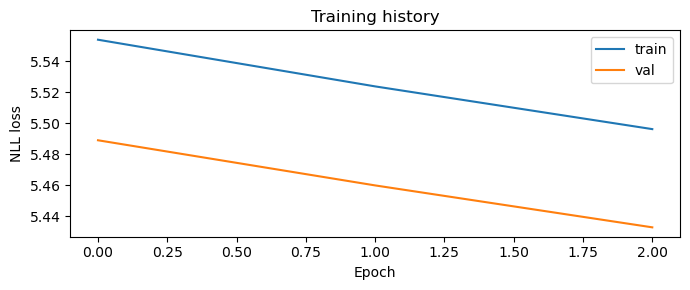

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL loss")
ax.legend()
ax.set_title("Training history")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_history.png"), dpi=100)
plt.show()

## 4  Validate against withheld test data

In [15]:
# Load the best checkpoint saved during training
model.load_state_dict(
    torch.load(str(OUTPUT_DIR / "best_model.pt"), map_location=DEVICE)
)
model.eval()
print("Best checkpoint loaded.")

Best checkpoint loaded.


/var/folders/w0/qvtthgds7m133drnqxl72fwr0000gn/T/ipykernel_15772/3353726289.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(str(OUTPUT_DIR / "best_model.pt"),

In [16]:
# Wrap the static rasters as a landscape-loader callable.
# Month index is ignored here because we have static (non-S2) layers.
ndvi_t  = torch.from_numpy(env_layers["ndvi"].astype(np.float32))
slope_t = torch.from_numpy(env_layers["slope"].astype(np.float32))

def get_landscape(_month_index):
    return [ndvi_t, slope_t]

In [17]:
# Use the last 10 % of steps as the test set (matches the DataLoader split)
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Validating on {len(test_sample):,} steps")

val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers — month doesn't matter
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

Validating on 1,029 steps


       habitat_prob   move_prob  next_step_prob
count    771.000000  771.000000      771.000000
mean       0.001586    0.014904        0.014855
std        0.000059    0.021862        0.021779
min        0.000000    0.000000        0.000000
25%        0.001585    0.002727        0.002719
50%        0.001586    0.006745        0.006729
75%        0.001588    0.017995        0.017961
max        0.001745    0.113747        0.113320


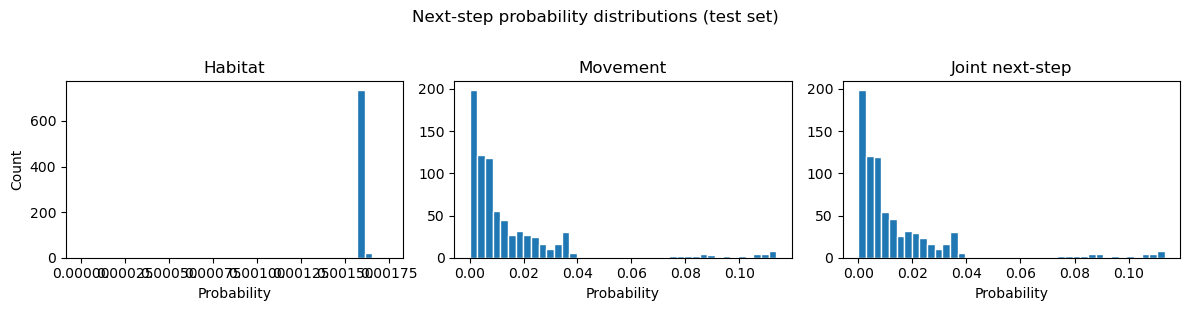

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, title in zip(
    axes,
    ["habitat_prob", "move_prob", "next_step_prob"],
    ["Habitat", "Movement", "Joint next-step"],
):
    data = val_results[col].dropna()
    ax.hist(data, bins=40, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Probability")
axes[0].set_ylabel("Count")
plt.suptitle("Next-step probability distributions (test set)", y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "validation_probs.png"), dpi=100)
plt.show()

## 5  Simulate a trajectory

In [ ]:
start_x = float(step_df["x1_"].median())
start_y = float(step_df["y1_"].median())
print(f"Starting location: ({start_x:.0f}, {start_y:.0f})")

sim_df = simulate_trajectory(
    model,
    get_landscape=get_landscape,
    transform=raster_transform,
    start_x=start_x,
    start_y=start_y,
    n_steps=1000,
    starting_yday=test_sample["yday_t1"].iloc[0],
    starting_hour=test_sample["hour_t1"].iloc[0],
    window_size=WINDOW_SIZE,
    month_index_fn=lambda _yday: 0,   # static layers
)
print(f"Simulated {len(sim_df)} steps")
sim_df.head()

Starting location: (36081, -1436907)


Simulated 100 steps


,x,y,hour,yday,month_index,hab_log_prob,move_log_prob,step_log_prob
0,36330.272779,-1.436885e+06,0.0,180.0,0,"[[-6.4221964, -6.404124, -6.404803, -6.411912,...","[[-8.946581, -8.840284, -8.731693, -8.620947, ...","[[-15.368777, -15.244408, -15.136496, -15.0328..."
1,36597.764883,-1.436758e+06,1.0,181.0,0,"[[-6.4189744, -6.4018455, -6.403147, -6.410141...","[[-8.886147, -8.777115, -8.665689, -8.552031, ...","[[-15.30512, -15.178961, -15.068836, -14.96217..."
2,36558.724292,-1.436491e+06,2.0,182.0,0,"[[-6.4200315, -6.4038215, -6.4132214, -6.41435...","[[-8.576057, -8.458664, -8.338818, -8.2168255,...","[[-14.996089, -14.862486, -14.752039, -14.6311..."
3,36489.072755,-1.436325e+06,3.0,183.0,0,"[[-6.4195595, -6.406848, -6.4164333, -6.418061...","[[-7.342986, -7.239093, -7.1364155, -7.035967,...","[[-13.762546, -13.645941, -13.552849, -13.4540..."
4,36467.806893,-1.436247e+06,4.0,184.0,0,"[[-6.420559, -6.4121346, -6.4165435, -6.421402...","[[-7.199677, -7.105266, -7.0131583, -6.9244647...","[[-13.620235, -13.517401, -13.429702, -13.3458..."


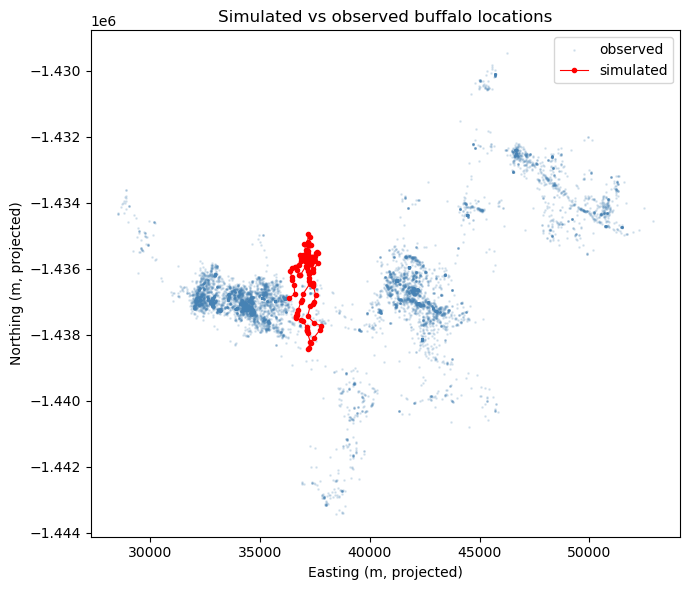

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    step_df["x1_"], step_df["y1_"],
    s=1, alpha=0.15, color="steelblue", label="observed",
)
ax.plot(
    sim_df["x"], sim_df["y"],
    "r-o", markersize=3, linewidth=0.8, label="simulated",
)
ax.set_xlabel("Easting (m, projected)")
ax.set_ylabel("Northing (m, projected)")
ax.legend()
ax.set_title("Simulated vs observed buffalo locations")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "simulated_trajectory.png"), dpi=100)
plt.show()